In [ ]:
# !pip install biopython

In [21]:
import gzip
from Bio import SeqIO
from typing import List
import matplotlib.pyplot as plt

In [3]:
fasta_file = r"C:\Users\carol\Downloads\human_g1k_v37.fasta.gz"

with gzip.open(fasta_file, "rt") as f:
    print(f.readline())  # Read just the first line


>1 dna:chromosome chromosome:GRCh37:1:1:249250621:1



In [4]:
with open(fasta_file, "rb") as f:
    print(f.read(2))

b'\x1f\x8b'


In [5]:
import os
print(os.path.getsize(fasta_file))  # Should be a big number


892331003


In [6]:
#Troubleshooted with ChatGPT gzip file error. Used their suggested way of only parsing out the chromosome
def extract_15mers_from_chr1(fasta_path):
    fifteen_mers = []

    with gzip.open(fasta_path, "rt") as handle:
        for record in SeqIO.parse(handle, "fasta"):
            if record.id.strip().lower() in ["1", "chr1"]:
                sequence = str(record.seq)
                for i in range(len(sequence) - 14):  # 15-mers
                    fifteen_mers.append(sequence[i:i+15])
                return fifteen_mers

# File path
fasta_file = r"C:\Users\carol\Downloads\human_g1k_v37.fasta.gz"

# Run the extraction
kmers = extract_15mers_from_chr1(fasta_file)

# Check a few
print(kmers[:5])


['NNNNNNNNNNNNNNN', 'NNNNNNNNNNNNNNN', 'NNNNNNNNNNNNNNN', 'NNNNNNNNNNNNNNN', 'NNNNNNNNNNNNNNN']


In [23]:
len(kmers)

249250607

In [8]:
#asked ChatGPT how to create a for loop that would drop any kmers that meet given criteria

filtered_kmers = []
for kmer in kmers:
    if kmer.count('N') <= 2:
        filtered_kmers.append(kmer)

len(filtered_kmers)

225280241

In [9]:
# visualize first 5 filtered kmers

print(filtered_kmers[:5])

['NNTAACCCTAACCCT', 'NTAACCCTAACCCTA', 'TAACCCTAACCCTAA', 'AACCCTAACCCTAAC', 'ACCCTAACCCTAACC']


In [10]:
# join all kmers into one string so it is useable by the rolling hash
kmers_string = ''.join(filtered_kmers)

In [11]:
# visualize to ensure joined 
print(kmers_string[:20])

NNTAACCCTAACCCTNTAAC


In [ ]:
import gzip
from Bio import SeqIO

def estimate_distinct_15mers_multihash(fasta_file, num_hashes=10, M=10**9 + 7):
    bases = [101 + i*2 for i in range(num_hashes)]  # Ensure different odd bases
    min_hashes = [None] * num_hashes
    window_size = 15

    with gzip.open(fasta_file, "rt") as handle:
        for record in SeqIO.parse(handle, "fasta"):
            if record.id.strip().lower() in ["1", "chr1"]:
                seq = str(record.seq)
                n = len(seq)

                for h, base in enumerate(bases):
                    power = [1] * window_size
                    for i in range(1, window_size):
                        power[i] = (power[i - 1] * base) % M

                    current_hash = 0
                    for i in range(window_size):
                        current_hash = (current_hash * base + ord(seq[i])) % M

                    min_hash = current_hash

                    for i in range(1, n - window_size + 1):
                        if 'N' in seq[i - 1:i + window_size]:  # Skip if 'N' in 15-mer
                            continue
                        current_hash = (
                            (current_hash - power[window_size - 1] * ord(seq[i - 1])) % M
                        )
                        current_hash = (current_hash * base + ord(seq[i + window_size - 1])) % M
                        if min_hash is None or current_hash < min_hash:
                            min_hash = current_hash

                    min_hashes[h] = min_hash

                break  # Only chromosome 1

    # Normalize and estimate
    normalized_mins = [h / M for h in min_hashes if h is not None]
    mean_min = sum(normalized_mins) / len(normalized_mins)
    estimated_distinct = (1 / mean_min) - 1 if mean_min > 0 else 0

    return estimated_distinct, normalized_mins, min_hashes, mean_min


In [15]:
hash_counts = [1, 2, 5, 10, 100]
estimates = []

for n_hash in hash_counts:
    est, _, _, _ = estimate_distinct_15mers_multihash(fasta_file, num_hashes=n_hash)
    print(f"{n_hash} hash(es): estimated = {int(est)}")
    estimates.append(est)

1 hash(es): estimated = 333333334
2 hash(es): estimated = 222222222
5 hash(es): estimated = 208333333
10 hash(es): estimated = 250000000
100 hash(es): estimated = 289017342


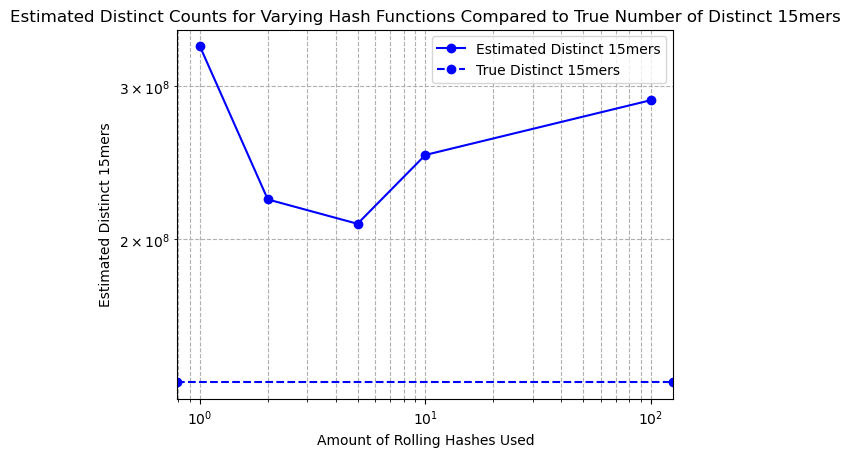

In [22]:
true_distinct = 136904144  

plt.figure()
plt.loglog(hash_counts, estimates, label='Estimated Distinct 15mers', marker='o', linestyle='-', color='blue')
plt.axhline(y=true_distinct, label='True Distinct 15mers', marker='o', linestyle='--', color ='blue')

plt.xlabel('Amount of Rolling Hashes Used')
plt.ylabel('Estimated Distinct 15mers')
plt.title('Estimated Distinct Counts for Varying Hash Functions Compared to True Number of Distinct 15mers')
plt.legend()

plt.grid(True, which="both", ls="--")
k = plt.savefig('distint_counts.png')
k
plt.show()
